## Noise Effect on Fidelity

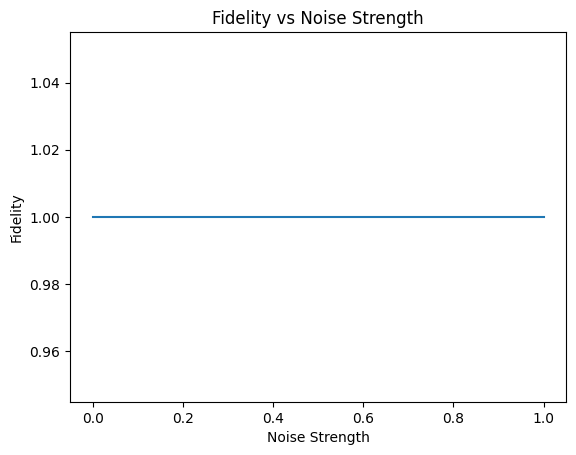

In [19]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from noise_models.amplitude_damping import amplitude_damping
from simulation.state_evolution import evolve_state, compute_fidelity_over_time

psi0 = basis(2, 0)
target = basis(2, 0)
H = 0 * sigmaz()

noise_vals = np.linspace(0, 1, 20)
fids = []

for g in noise_vals:
    tlist, states = evolve_state(H, psi0, [amplitude_damping(g)], T=5, steps=200)
    fids.append(fidelity(states[-1], target))

plt.plot(noise_vals, fids)
plt.xlabel("Noise Strength")
plt.ylabel("Fidelity")
plt.title("Fidelity vs Noise Strength")
plt.show()

## Bloch Sphere Evolution

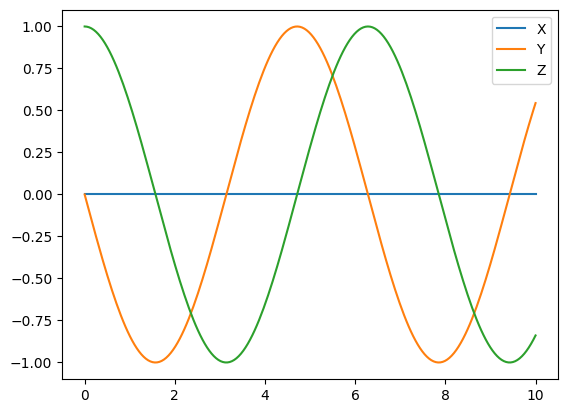

In [23]:
from simulation.state_evolution import compute_bloch_components

tlist, states = evolve_state(0.5*sigmax(), psi0, [], T=10)
bx, by, bz = compute_bloch_components(states)

plt.plot(tlist, bx, label="X")
plt.plot(tlist, by, label="Y")
plt.plot(tlist, bz, label="Z")
plt.legend()
plt.show()

## Compare Noise Models

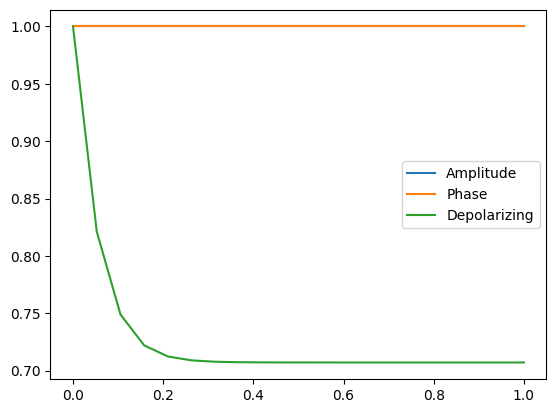

In [29]:
from noise_models.phase_damping import phase_damping
from noise_models.depolarizing_noise import depolarizing_noise

noise_vals = np.linspace(0,1,20)
amp_fid = []
phase_fid = []
depol_fid = []

for g in noise_vals:
    tlist, states = evolve_state(H, psi0, [amplitude_damping(g)])
    amp_fid.append(fidelity(states[-1], psi0))

    tlist, states = evolve_state(H, psi0, [phase_damping(g)])
    phase_fid.append(fidelity(states[-1], psi0))

    tlist, states = evolve_state(H, psi0, depolarizing_noise(g))
    depol_fid.append(fidelity(states[-1], psi0))

plt.plot(noise_vals, amp_fid, label="Amplitude")
plt.plot(noise_vals, phase_fid, label="Phase")
plt.plot(noise_vals, depol_fid, label="Depolarizing")
plt.legend()
plt.show()

## Control Pulse Effect

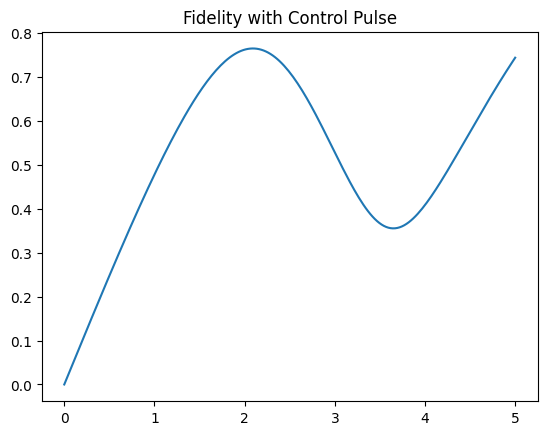

In [31]:
from control.control_pulse import gaussian_pulse
from control.controlled_evolution import run_controlled_simulation

tlist, states = run_controlled_simulation(gaussian_pulse, [])

target = basis(2, 1)
fids = [fidelity(s, target) for s in states]

plt.plot(tlist, fids)
plt.title("Fidelity with Control Pulse")
plt.show()